<a href="https://colab.research.google.com/github/p12Ivy0/PLTMH-ELC-QLSTM/blob/main/notebooks/04_validate_pi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import sys

REPO_URL = "https://github.com/p12Ivy0/PLTMH-ELC-QLSTM"
PROJECT_DIR = Path("/content/PLTMH-ELC-QLSTM")

if not PROJECT_DIR.exists():
    %cd /content
    !git clone {REPO_URL}

%cd /content/PLTMH-ELC-QLSTM

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("\nProject directory:")
!pwd

/content
Cloning into 'PLTMH-ELC-QLSTM'...
remote: Enumerating objects: 247, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 247 (delta 51), reused 39 (delta 21), pack-reused 165 (from 1)
Receiving objects: 100% (247/247), 646.70 KiB | 7.98 MiB/s, done.
Resolving deltas: 100% (113/113), done.
/content/PLTMH-ELC-QLSTM

Project directory:
/content/PLTMH-ELC-QLSTM


In [2]:
%cd /content/PLTMH-ELC-QLSTM

!git fetch origin
!git pull --rebase origin main

print("\n=== GIT STATUS ===")
!git status

/content/PLTMH-ELC-QLSTM
From https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
 * branch            main       -> FETCH_HEAD
Already up to date.

=== GIT STATUS ===
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [3]:
print("=== CONTROL FILES ===")

!ls -lh src/control
!ls -lh src/control/pi_controller.py
!ls -lh tests/test_pi.py

=== CONTROL FILES ===
total 16K
-rw-r--r-- 1 root root 1 Sep  5 11:23 gain_scheduler.py
-rw-r--r-- 1 root root 1 Sep  5 11:23 limiter.py
-rw-r--r-- 1 root root 1 Sep  5 11:23 pi_controller.py
-rw-r--r-- 1 root root 1 Sep  5 11:23 pwm.py
-rw-r--r-- 1 root root 1 Sep  5 11:23 src/control/pi_controller.py
-rw-r--r-- 1 root root 1 Sep  5 11:23 tests/test_pi.py


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


In [5]:
%%writefile /content/PLTMH-ELC-QLSTM/src/control/pi_controller.py

from dataclasses import dataclass
from typing import Callable, Optional

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

from ..plant.synchronous_generator import (
    GeneratorParams,
    electrical_base_speed_rad_s,
)

from ..plant.elc import ELCParams

from ..plant.dump_load import (
    average_dump_power_kw,
)


@dataclass(frozen=True)
class PIControllerParams:
    """
    Fixed-gain PI controller untuk ELC PLTMH.

    control_direction = -1:
        f < f_ref -> e > 0 -> duty ELC turun

    Unit:
        kp : duty / Hz
        ki : duty / (Hz s)
    """

    kp: float = 0.10
    ki: float = 0.50

    reference_frequency_hz: float = 50.0

    output_bias: float = 0.20

    output_min: float = 0.0
    output_max: float = 1.0

    control_direction: float = -1.0

    def __post_init__(self):

        if self.kp < 0.0:
            raise ValueError(
                "kp must be non-negative."
            )

        if self.ki < 0.0:
            raise ValueError(
                "ki must be non-negative."
            )

        if not (
            self.output_min
            < self.output_max
        ):
            raise ValueError(
                "output_min must be smaller "
                "than output_max."
            )

        if not (
            self.output_min
            <= self.output_bias
            <= self.output_max
        ):
            raise ValueError(
                "output_bias must lie within "
                "output limits."
            )

        if self.control_direction not in (
            -1.0,
            1.0,
        ):
            raise ValueError(
                "control_direction must be "
                "-1 or +1."
            )


def frequency_error_hz(
    reference_frequency_hz: float,
    measured_frequency_hz: float,
) -> float:
    """
    e = f_ref - f
    """

    return float(
        reference_frequency_hz
        - measured_frequency_hz
    )


def pi_raw_output(
    error_hz: float,
    integral_error_hz_s: float,
    params: PIControllerParams,
) -> float:
    """
    Unsaturated duty-cycle command.
    """

    correction = (
        params.kp
        * error_hz
        +
        params.ki
        * integral_error_hz_s
    )

    output = (
        params.output_bias
        +
        params.control_direction
        * correction
    )

    return float(output)


def saturate_pi_output(
    raw_output: float,
    params: PIControllerParams,
) -> float:
    """
    Saturasi duty cycle.
    """

    return float(
        np.clip(
            raw_output,
            params.output_min,
            params.output_max,
        )
    )


def pi_output(
    error_hz: float,
    integral_error_hz_s: float,
    params: PIControllerParams,
):
    """
    Mengembalikan:
        raw duty,
        saturated duty.
    """

    raw = pi_raw_output(
        error_hz,
        integral_error_hz_s,
        params,
    )

    saturated = saturate_pi_output(
        raw,
        params,
    )

    return raw, saturated


def conditional_integrator_derivative(
    error_hz: float,
    raw_output: float,
    params: PIControllerParams,
) -> float:
    """
    Conditional-integration anti-windup.

    Integrator dihentikan bila error akan
    mendorong PI semakin jauh ke daerah saturasi.
    """

    output_rate_sign = (
        params.control_direction
        * params.ki
        * error_hz
    )

    if (
        raw_output < params.output_min
        and output_rate_sign < 0.0
    ):
        return 0.0

    if (
        raw_output > params.output_max
        and output_rate_sign > 0.0
    ):
        return 0.0

    return float(error_hz)


def closed_loop_rhs(
    t: float,
    x: np.ndarray,
    controller_params: PIControllerParams,
    generator_params: GeneratorParams,
    elc_params: ELCParams,
    mechanical_power_profile: Callable[[float], float],
    consumer_power_profile: Callable[[float], float],
):
    """
    Closed-loop states:

        x[0] = omega_pu
        x[1] = delta_rad
        x[2] = P_dump actual [kW]
        x[3] = integral error [Hz s]
    """

    omega_pu = float(x[0])
    dump_power_kw = float(x[2])
    integral_error = float(x[3])

    frequency_hz = (
        generator_params.nominal_frequency_hz
        * omega_pu
    )

    error_hz = frequency_error_hz(
        controller_params.reference_frequency_hz,
        frequency_hz,
    )

    raw_duty, duty = pi_output(
        error_hz,
        integral_error,
        controller_params,
    )

    d_integral_dt = (
        conditional_integrator_derivative(
            error_hz,
            raw_duty,
            controller_params,
        )
    )

    dump_command_kw = (
        average_dump_power_kw(
            duty,
            elc_params.dump_load,
        )
    )

    d_dump_dt = (
        dump_command_kw
        - dump_power_kw
    ) / (
        elc_params.actuator_time_constant_s
    )

    consumer_power_kw = float(
        consumer_power_profile(t)
    )

    electrical_power_kw = (
        consumer_power_kw
        + dump_power_kw
    )

    pe_pu = (
        electrical_power_kw
        / generator_params.rated_power_kw
    )

    pm_pu = float(
        mechanical_power_profile(t)
    )

    d_omega_dt = (
        pm_pu
        - pe_pu
        - generator_params.damping_pu
        * (omega_pu - 1.0)
    ) / (
        2.0
        * generator_params.inertia_constant_s
    )

    d_delta_dt = (
        electrical_base_speed_rad_s(
            generator_params
        )
        * (omega_pu - 1.0)
    )

    return np.array([
        d_omega_dt,
        d_delta_dt,
        d_dump_dt,
        d_integral_dt,
    ])


def simulate_pi_elc_closed_loop(
    controller_params: PIControllerParams,
    generator_params: GeneratorParams,
    elc_params: ELCParams,
    mechanical_power_profile: Callable[[float], float],
    consumer_power_profile: Callable[[float], float],
    t_end_s: float = 10.0,
    dt_s: float = 0.005,
    initial_omega_pu: float = 1.0,
    initial_delta_rad: float = 0.0,
    initial_integral_error_hz_s: float = 0.0,
    initial_dump_power_kw: Optional[float] = None,
) -> pd.DataFrame:
    """
    Simulasi closed-loop:
    generator + ELC + fixed-gain PI.
    """

    initial_frequency_hz = (
        generator_params.nominal_frequency_hz
        * initial_omega_pu
    )

    initial_error_hz = frequency_error_hz(
        controller_params.reference_frequency_hz,
        initial_frequency_hz,
    )

    _, initial_duty = pi_output(
        initial_error_hz,
        initial_integral_error_hz_s,
        controller_params,
    )

    if initial_dump_power_kw is None:

        initial_dump_power_kw = (
            average_dump_power_kw(
                initial_duty,
                elc_params.dump_load,
            )
        )

    x0 = np.array([
        initial_omega_pu,
        initial_delta_rad,
        initial_dump_power_kw,
        initial_integral_error_hz_s,
    ])

    n_steps = int(
        round(t_end_s / dt_s)
    )

    t_eval = np.linspace(
        0.0,
        t_end_s,
        n_steps + 1,
    )

    solution = solve_ivp(
        fun=lambda t, x: closed_loop_rhs(
            t,
            x,
            controller_params,
            generator_params,
            elc_params,
            mechanical_power_profile,
            consumer_power_profile,
        ),
        t_span=(
            0.0,
            t_end_s,
        ),
        y0=x0,
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=dt_s,
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    time_s = solution.t

    omega_pu = solution.y[0]
    delta_rad = solution.y[1]
    dump_power_kw = solution.y[2]
    integral_error = solution.y[3]

    frequency_hz = (
        generator_params.nominal_frequency_hz
        * omega_pu
    )

    error_hz = (
        controller_params.reference_frequency_hz
        - frequency_hz
    )

    raw_duty = np.zeros_like(
        time_s
    )

    duty = np.zeros_like(
        time_s
    )

    for i in range(len(time_s)):

        raw_duty[i], duty[i] = (
            pi_output(
                error_hz[i],
                integral_error[i],
                controller_params,
            )
        )

    dump_command_kw = (
        average_dump_power_kw(
            duty,
            elc_params.dump_load,
        )
    )

    consumer_power_kw = np.array([
        consumer_power_profile(t)
        for t in time_s
    ])

    pm_pu = np.array([
        mechanical_power_profile(t)
        for t in time_s
    ])

    electrical_power_kw = (
        consumer_power_kw
        + dump_power_kw
    )

    pe_pu = (
        electrical_power_kw
        / generator_params.rated_power_kw
    )

    power_mismatch_pu = (
        pm_pu
        - pe_pu
    )

    rocof_hz_s = np.gradient(
        frequency_hz,
        time_s,
    )

    return pd.DataFrame({
        "time_s": time_s,
        "frequency_hz": frequency_hz,
        "error_hz": error_hz,
        "omega_pu": omega_pu,
        "delta_rad": delta_rad,
        "integral_error_hz_s": integral_error,
        "raw_duty": raw_duty,
        "duty": duty,
        "dump_command_kw": dump_command_kw,
        "dump_power_kw": dump_power_kw,
        "consumer_power_kw": consumer_power_kw,
        "electrical_power_kw": electrical_power_kw,
        "pm_pu": pm_pu,
        "pe_pu": pe_pu,
        "power_mismatch_pu": power_mismatch_pu,
        "rocof_hz_s": rocof_hz_s,
    })

Overwriting /content/PLTMH-ELC-QLSTM/src/control/pi_controller.py


In [6]:
%%writefile /content/PLTMH-ELC-QLSTM/src/control/__init__.py

from .pi_controller import (
    PIControllerParams,
    frequency_error_hz,
    pi_raw_output,
    saturate_pi_output,
    pi_output,
    conditional_integrator_derivative,
    closed_loop_rhs,
    simulate_pi_elc_closed_loop,
)

Writing /content/PLTMH-ELC-QLSTM/src/control/__init__.py


In [7]:
from src.control import (
    PIControllerParams,
    frequency_error_hz,
    pi_raw_output,
    saturate_pi_output,
    pi_output,
    conditional_integrator_derivative,
    simulate_pi_elc_closed_loop,
)

print(
    "PASS: PI controller berhasil di-import."
)

PASS: PI controller berhasil di-import.


In [8]:
pi_params = PIControllerParams(
    kp=0.10,
    ki=0.50,
    reference_frequency_hz=50.0,
    output_bias=0.20,
    output_min=0.0,
    output_max=1.0,
    control_direction=-1.0,
)

print(pi_params)

PIControllerParams(kp=0.1, ki=0.5, reference_frequency_hz=50.0, output_bias=0.2, output_min=0.0, output_max=1.0, control_direction=-1.0)


In [9]:
error_low_frequency = frequency_error_hz(
    50.0,
    49.5
)

error_high_frequency = frequency_error_hz(
    50.0,
    50.5
)

_, duty_low_frequency = pi_output(
    error_low_frequency,
    0.0,
    pi_params,
)

_, duty_high_frequency = pi_output(
    error_high_frequency,
    0.0,
    pi_params,
)

print(
    "Duty at 49.5 Hz:",
    duty_low_frequency
)

print(
    "Duty at 50.5 Hz:",
    duty_high_frequency
)

assert duty_low_frequency < 0.20
assert duty_high_frequency > 0.20

print(
    "PASS: PI control direction valid."
)

Duty at 49.5 Hz: 0.15000000000000002
Duty at 50.5 Hz: 0.25
PASS: PI control direction valid.


In [10]:
raw_low = pi_raw_output(
    error_hz=5.0,
    integral_error_hz_s=10.0,
    params=pi_params,
)

sat_low = saturate_pi_output(
    raw_low,
    pi_params,
)

di_low = conditional_integrator_derivative(
    error_hz=5.0,
    raw_output=raw_low,
    params=pi_params,
)

print("Raw output       :", raw_low)
print("Saturated output :", sat_low)
print("dI/dt            :", di_low)

assert sat_low == 0.0
assert di_low == 0.0

print(
    "PASS: lower saturation anti-windup valid."
)

Raw output       : -5.3
Saturated output : 0.0
dI/dt            : 0.0
PASS: lower saturation anti-windup valid.


In [11]:
from src.plant import (
    GeneratorParams,
    DumpLoadParams,
    ELCParams,
)

gen_params = GeneratorParams(
    rated_power_kw=100.0,
    nominal_frequency_hz=50.0,
    poles=4,
    inertia_constant_s=2.5,
    damping_pu=2.0,
)

dump_params = DumpLoadParams(
    rated_power_kw=100.0
)

elc_params = ELCParams(
    dump_load=dump_params,
    actuator_time_constant_s=0.05,
)

print(gen_params)
print(elc_params)

GeneratorParams(rated_power_kw=100.0, nominal_frequency_hz=50.0, poles=4, inertia_constant_s=2.5, damping_pu=2.0)
ELCParams(dump_load=DumpLoadParams(rated_power_kw=100.0, duty_min=0.0, duty_max=1.0), actuator_time_constant_s=0.05)


In [14]:
steady_result = simulate_pi_elc_closed_loop(
    controller_params=pi_params,
    generator_params=gen_params,
    elc_params=elc_params,
    mechanical_power_profile=lambda t: 1.0,
    consumer_power_profile=lambda t: 80.0,
    t_end_s=5.0,
    dt_s=0.005,
)

steady_result.head()

print(
    "Final frequency:",
    steady_result["frequency_hz"].iloc[-1]
)

print(
    "Final dump power:",
    steady_result["dump_power_kw"].iloc[-1]
)

print(
    "Final duty:",
    steady_result["duty"].iloc[-1]
)

assert np.isclose(
    steady_result[
        "frequency_hz"
    ].iloc[-1],
    50.0,
    atol=1e-6,
)

assert np.isclose(
    steady_result[
        "dump_power_kw"
    ].iloc[-1],
    20.0,
    atol=1e-6,
)

print(
    "PASS: closed-loop equilibrium valid."
)

Final frequency: 50.0
Final dump power: 20.0
Final duty: 0.2
PASS: closed-loop equilibrium valid.


In [15]:
load_increase_profile = (
    lambda t:
    80.0 if t < 2.0
    else 90.0
)

pi_load_increase = (
    simulate_pi_elc_closed_loop(
        controller_params=pi_params,
        generator_params=gen_params,
        elc_params=elc_params,
        mechanical_power_profile=lambda t: 1.0,
        consumer_power_profile=load_increase_profile,
        t_end_s=10.0,
        dt_s=0.005,
    )
)

In [16]:
open_loop_params = replace(
    pi_params,
    kp=0.0,
    ki=0.0,
)

open_loop_load_increase = (
    simulate_pi_elc_closed_loop(
        controller_params=open_loop_params,
        generator_params=gen_params,
        elc_params=elc_params,
        mechanical_power_profile=lambda t: 1.0,
        consumer_power_profile=load_increase_profile,
        t_end_s=10.0,
        dt_s=0.005,
    )
)

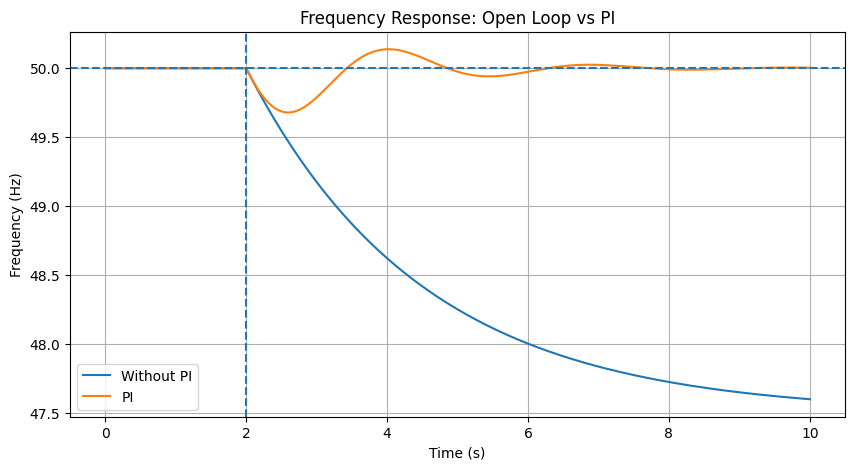

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    open_loop_load_increase["time_s"],
    open_loop_load_increase["frequency_hz"],
    label="Without PI"
)

plt.plot(
    pi_load_increase["time_s"],
    pi_load_increase["frequency_hz"],
    label="PI"
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "Frequency Response: Open Loop vs PI"
)

plt.legend()
plt.grid(True)
plt.show()

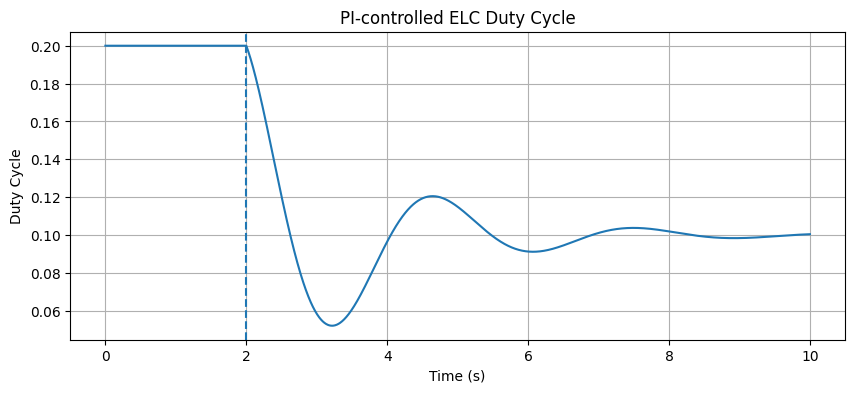

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    pi_load_increase["time_s"],
    pi_load_increase["duty"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Duty Cycle")
plt.title(
    "PI-controlled ELC Duty Cycle"
)

plt.grid(True)
plt.show()

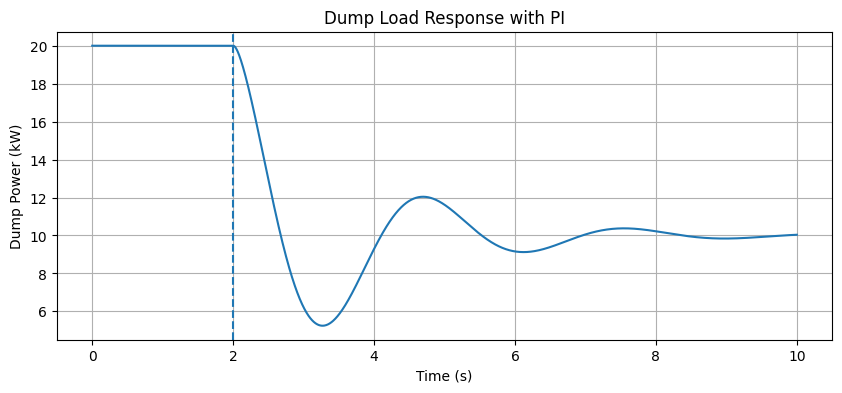

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(
    pi_load_increase["time_s"],
    pi_load_increase["dump_power_kw"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Dump Power (kW)")
plt.title(
    "Dump Load Response with PI"
)

plt.grid(True)
plt.show()

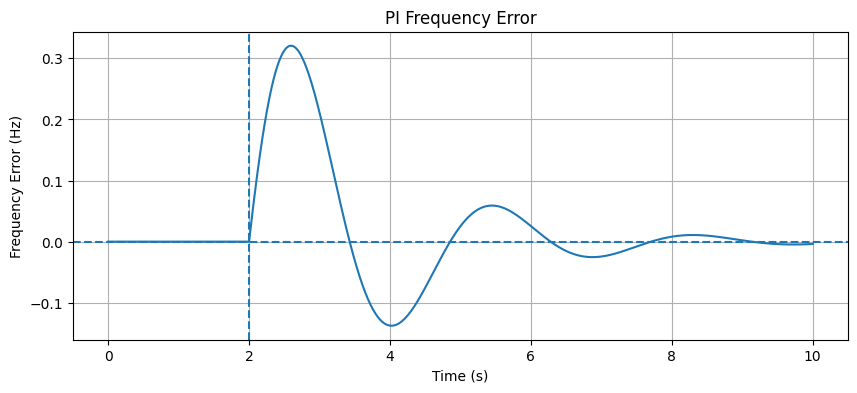

In [20]:
plt.figure(figsize=(10, 4))

plt.plot(
    pi_load_increase["time_s"],
    pi_load_increase["error_hz"]
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency Error (Hz)")
plt.title(
    "PI Frequency Error"
)

plt.grid(True)
plt.show()

In [21]:
def response_metrics(
    df,
    disturbance_time_s=2.0,
    reference_frequency_hz=50.0,
    settling_band_hz=0.05,
):
    post = df[
        df["time_s"]
        >= disturbance_time_s
    ].copy()

    deviation = (
        post["frequency_hz"]
        - reference_frequency_hz
    )

    peak_abs_deviation = (
        np.abs(deviation).max()
    )

    rmse = np.sqrt(
        np.mean(
            deviation.to_numpy() ** 2
        )
    )

    max_rocof = np.max(
        np.abs(
            post["rocof_hz_s"]
        )
    )

    outside = post[
        np.abs(deviation)
        > settling_band_hz
    ]

    if len(outside) == 0:
        settling_time_s = 0.0

    elif (
        outside["time_s"].iloc[-1]
        >= post["time_s"].iloc[-1]
        - 1e-9
    ):
        settling_time_s = np.nan

    else:
        settling_time_s = (
            outside["time_s"].iloc[-1]
            - disturbance_time_s
        )

    return {
        "peak_abs_deviation_hz":
            peak_abs_deviation,

        "rmse_frequency_hz":
            rmse,

        "max_rocof_hz_s":
            max_rocof,

        "settling_time_s":
            settling_time_s,
    }

In [22]:
open_metrics = response_metrics(
    open_loop_load_increase
)

pi_metrics = response_metrics(
    pi_load_increase
)

comparison = pd.DataFrame(
    [
        open_metrics,
        pi_metrics,
    ],
    index=[
        "Without PI",
        "PI",
    ]
)

comparison

,peak_abs_deviation_hz,rmse_frequency_hz,max_rocof_hz_s,settling_time_s
Without PI,2.398094,1.864817,0.997997,NaN
PI,0.320654,0.104635,0.997669,3.705


In [23]:
final_frequency = (
    pi_load_increase[
        "frequency_hz"
    ].iloc[-1]
)

final_dump = (
    pi_load_increase[
        "dump_power_kw"
    ].iloc[-1]
)

print(
    "Final frequency:",
    final_frequency
)

print(
    "Final dump power:",
    final_dump
)

assert abs(
    final_frequency - 50.0
) < 0.05

assert np.isclose(
    final_dump,
    10.0,
    atol=0.5,
)

assert (
    pi_metrics[
        "peak_abs_deviation_hz"
    ]
    <
    open_metrics[
        "peak_abs_deviation_hz"
    ]
)

print(
    "PASS: PI improves frequency regulation."
)

Final frequency: 50.00387400570885
Final dump power: 10.037642663080755
PASS: PI improves frequency regulation.


In [24]:
load_decrease_profile = (
    lambda t:
    80.0 if t < 2.0
    else 60.0
)

pi_load_decrease = (
    simulate_pi_elc_closed_loop(
        controller_params=pi_params,
        generator_params=gen_params,
        elc_params=elc_params,
        mechanical_power_profile=lambda t: 1.0,
        consumer_power_profile=load_decrease_profile,
        t_end_s=10.0,
        dt_s=0.005,
    )
)

In [25]:
final_frequency_drop = (
    pi_load_decrease[
        "frequency_hz"
    ].iloc[-1]
)

final_dump_drop = (
    pi_load_decrease[
        "dump_power_kw"
    ].iloc[-1]
)

print(
    "Final frequency:",
    final_frequency_drop
)

print(
    "Final dump power:",
    final_dump_drop
)

assert abs(
    final_frequency_drop - 50.0
) < 0.05

assert np.isclose(
    final_dump_drop,
    40.0,
    atol=0.5,
)

print(
    "PASS: PI handles consumer load reduction."
)

Final frequency: 49.99225199107074
Final dump power: 39.924714598986924
PASS: PI handles consumer load reduction.


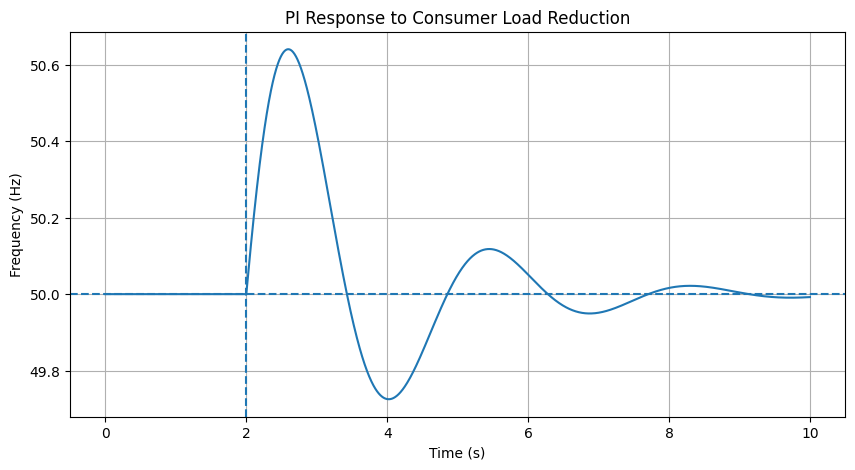

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    pi_load_decrease["time_s"],
    pi_load_decrease["frequency_hz"]
)

plt.axhline(
    50.0,
    linestyle="--"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(
    "PI Response to Consumer Load Reduction"
)

plt.grid(True)
plt.show()

In [27]:
kp_values = [
    0.03,
    0.06,
    0.10,
    0.15,
]

kp_results = []

for kp_value in kp_values:

    params_test = replace(
        pi_params,
        kp=kp_value,
        ki=0.50,
    )

    result = (
        simulate_pi_elc_closed_loop(
            controller_params=params_test,
            generator_params=gen_params,
            elc_params=elc_params,
            mechanical_power_profile=lambda t: 1.0,
            consumer_power_profile=load_increase_profile,
            t_end_s=10.0,
            dt_s=0.005,
        )
    )

    metrics = response_metrics(
        result
    )

    metrics["kp"] = kp_value

    kp_results.append(
        metrics
    )

kp_table = pd.DataFrame(
    kp_results
)

kp_table

,peak_abs_deviation_hz,rmse_frequency_hz,max_rocof_hz_s,settling_time_s,kp
0,0.385915,0.164617,0.997899,NaN,0.03
1,0.355193,0.129292,0.997793,5.235,0.06
2,0.320654,0.104635,0.997669,3.705,0.10
3,0.285413,0.087413,0.997508,2.455,0.15


In [28]:
ki_values = [
    0.10,
    0.30,
    0.50,
    0.80,
]

ki_results = []

for ki_value in ki_values:

    params_test = replace(
        pi_params,
        kp=0.10,
        ki=ki_value,
    )

    result = (
        simulate_pi_elc_closed_loop(
            controller_params=params_test,
            generator_params=gen_params,
            elc_params=elc_params,
            mechanical_power_profile=lambda t: 1.0,
            consumer_power_profile=load_increase_profile,
            t_end_s=10.0,
            dt_s=0.005,
        )
    )

    metrics = response_metrics(
        result
    )

    metrics["ki"] = ki_value

    ki_results.append(
        metrics
    )

ki_table = pd.DataFrame(
    ki_results
)

ki_table

,peak_abs_deviation_hz,rmse_frequency_hz,max_rocof_hz_s,settling_time_s,ki
0,0.473912,0.215283,0.997672,3.600,0.1
1,0.368504,0.129378,0.997671,3.345,0.3
2,0.320654,0.104635,0.997669,3.705,0.5
3,0.279276,0.088860,0.997667,3.900,0.8


In [29]:
%%writefile /content/PLTMH-ELC-QLSTM/tests/test_pi.py

import numpy as np

from src.control import (
    PIControllerParams,
    frequency_error_hz,
    pi_output,
    pi_raw_output,
    saturate_pi_output,
    conditional_integrator_derivative,
    simulate_pi_elc_closed_loop,
)

from src.plant import (
    GeneratorParams,
    DumpLoadParams,
    ELCParams,
)


def make_system():

    controller = PIControllerParams(
        kp=0.10,
        ki=0.50,
        output_bias=0.20,
        control_direction=-1.0,
    )

    generator = GeneratorParams()

    elc = ELCParams(
        dump_load=DumpLoadParams(
            rated_power_kw=100.0
        ),
        actuator_time_constant_s=0.05,
    )

    return (
        controller,
        generator,
        elc,
    )


def test_frequency_error_sign():

    assert (
        frequency_error_hz(
            50.0,
            49.5
        )
        > 0.0
    )

    assert (
        frequency_error_hz(
            50.0,
            50.5
        )
        < 0.0
    )


def test_elc_control_direction():

    controller, _, _ = make_system()

    _, low_frequency_duty = pi_output(
        0.5,
        0.0,
        controller,
    )

    _, high_frequency_duty = pi_output(
        -0.5,
        0.0,
        controller,
    )

    assert low_frequency_duty < 0.20
    assert high_frequency_duty > 0.20


def test_pi_saturation():

    controller, _, _ = make_system()

    assert (
        saturate_pi_output(
            -10.0,
            controller
        )
        == 0.0
    )

    assert (
        saturate_pi_output(
            10.0,
            controller
        )
        == 1.0
    )


def test_anti_windup_lower_limit():

    controller, _, _ = make_system()

    raw = pi_raw_output(
        error_hz=5.0,
        integral_error_hz_s=10.0,
        params=controller,
    )

    derivative = (
        conditional_integrator_derivative(
            error_hz=5.0,
            raw_output=raw,
            params=controller,
        )
    )

    assert raw < 0.0
    assert derivative == 0.0


def test_closed_loop_equilibrium():

    controller, generator, elc = (
        make_system()
    )

    result = (
        simulate_pi_elc_closed_loop(
            controller_params=controller,
            generator_params=generator,
            elc_params=elc,
            mechanical_power_profile=lambda t: 1.0,
            consumer_power_profile=lambda t: 80.0,
            t_end_s=3.0,
            dt_s=0.005,
        )
    )

    assert np.isclose(
        result[
            "frequency_hz"
        ].iloc[-1],
        50.0,
        atol=1e-6,
    )


def test_pi_recovers_load_increase():

    controller, generator, elc = (
        make_system()
    )

    result = (
        simulate_pi_elc_closed_loop(
            controller_params=controller,
            generator_params=generator,
            elc_params=elc,
            mechanical_power_profile=lambda t: 1.0,
            consumer_power_profile=lambda t: (
                80.0
                if t < 2.0
                else 90.0
            ),
            t_end_s=10.0,
            dt_s=0.005,
        )
    )

    assert abs(
        result[
            "frequency_hz"
        ].iloc[-1]
        - 50.0
    ) < 0.05

    assert np.isclose(
        result[
            "dump_power_kw"
        ].iloc[-1],
        10.0,
        atol=0.5,
    )


def test_pi_recovers_load_decrease():

    controller, generator, elc = (
        make_system()
    )

    result = (
        simulate_pi_elc_closed_loop(
            controller_params=controller,
            generator_params=generator,
            elc_params=elc,
            mechanical_power_profile=lambda t: 1.0,
            consumer_power_profile=lambda t: (
                80.0
                if t < 2.0
                else 60.0
            ),
            t_end_s=10.0,
            dt_s=0.005,
        )
    )

    assert abs(
        result[
            "frequency_hz"
        ].iloc[-1]
        - 50.0
    ) < 0.05

    assert np.isclose(
        result[
            "dump_power_kw"
        ].iloc[-1],
        40.0,
        atol=0.5,
    )

Overwriting /content/PLTMH-ELC-QLSTM/tests/test_pi.py


In [30]:
%cd /content/PLTMH-ELC-QLSTM

!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_pi.py

/content/PLTMH-ELC-QLSTM
.......                                                                  [100%]
7 passed in 3.20s


In [31]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_elc.py

........                                                                 [100%]
8 passed in 2.16s


In [32]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_plant_model.py

....                                                                     [100%]
4 passed in 1.59s


In [33]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q

........................                                                 [100%]
24 passed in 6.82s


In [34]:
%cd /content/PLTMH-ELC-QLSTM

!git status

/content/PLTMH-ELC-QLSTM
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/control/pi_controller.py
	modified:   tests/test_pi.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	src/control/__init__.py

no changes added to commit (use "git add" and/or "git commit -a")


In [35]:
!git add src/control/__init__.py
!git add src/control/pi_controller.py
!git add tests/test_pi.py

!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/control/__init__.py
	modified:   src/control/pi_controller.py
	modified:   tests/test_pi.py



In [36]:
!git config --global user.name "p12Ivy0"
!git config --global user.email "ypriyogunos@gmail.com"

!git commit -m "Add fixed-gain PI baseline and closed-loop validation"

[main 5cffc61] Add fixed-gain PI baseline and closed-loop validation
 3 files changed, 719 insertions(+)
 create mode 100644 src/control/__init__.py


In [37]:
import shutil

gh_path = shutil.which("gh")

print(
    "GitHub CLI path:",
    gh_path
)

if gh_path is None:
    raise RuntimeError(
        "GitHub CLI belum tersedia."
    )

print(
    "PASS: GitHub CLI tersedia."
)

GitHub CLI path: /usr/bin/gh
PASS: GitHub CLI tersedia.


In [38]:
!gh --version

gh version 2.98.0 (2026-08-20)
https://github.com/cli/cli/releases/tag/v2.98.0


In [39]:
from google.colab import userdata

github_token = userdata.get(
    "GITHUB_TOKEN"
)

if github_token:
    print(
        "PASS: GITHUB_TOKEN berhasil dibaca "
        "dari Colab Secrets."
    )
else:
    raise RuntimeError(
        "GITHUB_TOKEN tidak ditemukan."
    )

PASS: GITHUB_TOKEN berhasil dibaca dari Colab Secrets.


In [40]:
import subprocess

auth_result = subprocess.run(
    [
        "gh",
        "auth",
        "login",
        "--hostname",
        "github.com",
        "--git-protocol",
        "https",
        "--with-token",
    ],
    input=github_token,
    text=True,
    capture_output=True,
)

if auth_result.returncode == 0:
    print(
        "PASS: autentikasi GitHub CLI berhasil."
    )
else:
    print(
        auth_result.stderr
    )

PASS: autentikasi GitHub CLI berhasil.


In [41]:
!gh auth setup-git

In [42]:
!gh auth status

github.com
  ✓ Logged in to github.com account p12Ivy0 (/root/.config/gh/hosts.yml)
  - Active account: true
  - Git operations protocol: https
  - Token: github_pat_**********************************************************************************


In [43]:
print("=== GIT IDENTITY ===")

!git config --global user.name
!git config --global user.email

print("\n=== REMOTE ===")

!git remote -v

=== GIT IDENTITY ===
p12Ivy0
ypriyogunos@gmail.com

=== REMOTE ===
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (fetch)
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (push)


In [44]:
!git ls-remote origin HEAD

d5fc1a48db62084887c7ef53e9d1c1255297c881	HEAD


In [45]:
%cd /content/PLTMH-ELC-QLSTM

!git fetch origin
!git status

/content/PLTMH-ELC-QLSTM
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [46]:
!git pull --rebase origin main

From https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.


In [47]:
!git log -8 --oneline --graph --decorate --all

* 5cffc61 (HEAD -> main) Add fixed-gain PI baseline and closed-loop validation
* d5fc1a4 (origin/main, origin/HEAD) Update ELC validation notebook
* 53ab22a Add averaged ELC and dump load validation model
* db8cc8f Add synchronous generator model and validation tests
* 2750f4d Update synchronous generator validation notebook
* cb5c612 Created using Colab
* dc8da34 Created using Colab
* 204ab76 Add reduced-order synchronous generator model and tests


In [48]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [49]:
!git push origin main

Enumerating objects: 14, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 3.63 KiB | 1.82 MiB/s, done.
Total 8 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 3 local objects.
To https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
   d5fc1a4..5cffc61  main -> main


In [50]:
!git fetch origin
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
